# Módulo 5 · Clase 4 — ¿Qué me está avisando el agua?

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### El encargo

Tenemos una plataforma con 82 campos activos. La planta que trata el agua
tiene capacidad fija, y ampliarla toma cinco años.

> **¿Cuáles de nuestros campos van a estar ahogados en agua dentro de cinco
> años — y a cuáles les dedicamos la gente que tenemos?**

### Lo que se llevan de este cuaderno

1. Calcular **corte de agua**, **WOR** y **GOR** desde los barriles crudos.
2. Encontrar el día en que **llegó el agua** a cada campo (*breakthrough*), y
   alinear toda la flota con ese reloj.
3. Agrupar las curvas con **K-means** — y **someter el agrupamiento a un
   examen**, que es la parte que casi nadie hace.
4. Montar un **pronóstico a cinco años** con cuatro métodos, y calificarlos
   con 885 exámenes honestos.
5. Convertir el pronóstico en una **lista de vigilancia** con nombres.

### Cómo trabajamos acá

Nada se da por sabido. Cada concepto se explica cuando aparece, aunque ya
haya salido en otro módulo. Y **ningún número de este cuaderno está escrito a
mano**: todos salen de una celda que se puede volver a correr.

## 0 · Las herramientas

Las mismas de siempre. `pandas` para las tablas, `numpy` para las cuentas,
`matplotlib` para los gráficos, y de `scikit-learn` tres piezas que vamos a
explicar cuando las usemos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans                    # agrupar sin etiquetas
from sklearn.ensemble import RandomForestRegressor    # el bosque
from sklearn.model_selection import GroupKFold        # validar por campo

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#E5E7EB", "axes.spines.top": False,
                     "axes.spines.right": False, "figure.figsize": (10, 4)})

# la paleta de la clase: el agua siempre del mismo color
AZUL_AGUA, NEGRO_OIL = "#0E7490", "#2D2D2D"
ROJO, VERDE, GRIS, NARANJA = "#C82B40", "#16A34A", "#9CA3AF", "#EA580C"

print("listo")

listo


## 1 · El dato: producción mensual de la plataforma noruega

Viene del **Sokkeldirektoratet** (el regulador noruego), que publica mes a mes
lo que produjo cada campo. Es la misma fuente de la Clase 3 — pero aquella vez
usamos solo la columna del petróleo. Hoy usamos las tres.

| columna | qué es |
|---|---|
| `campo` | nombre del campo |
| `fecha` | primer día del mes |
| `dias` | días que tiene ese mes (28, 30, 31) |
| `oil_bpd` | petróleo, en barriles por día |
| `agua_bpd` | agua producida, en barriles por día |
| `gas_ksm3d` | gas, en miles de Sm³ por día |

Ojo con una cosa: `oil_bpd` es un **caudal** (barriles *por día*), no un total.
Para saber cuántos barriles salieron en un mes hay que multiplicar por `dias`.
Por eso la columna `dias` está ahí.

In [2]:
URL = ("https://raw.githubusercontent.com/cmosquerat/slb-diplomado/"
       "main/datos/campos_noruega_agua.csv")

d = pd.read_csv(URL, parse_dates=["fecha"])

print(f"filas:  {len(d):,}")
print(f"campos: {d.campo.nunique()}")
print(f"desde:  {d.fecha.min().date()}   hasta: {d.fecha.max().date()}")
d.head()

filas:  25,054
campos: 107
desde:  1971-06-01   hasta: 2026-05-01


,campo,fecha,dias,oil_bpd,agua_bpd,gas_ksm3d
0,16/1-12 Troldhaugen,2021-08-01,31,1324.9,0.0,0.00
1,16/1-12 Troldhaugen,2021-09-01,30,5394.6,1507.5,57.67
2,16/1-12 Troldhaugen,2021-10-01,31,2378.0,1850.4,80.65
3,16/1-12 Troldhaugen,2021-11-01,30,2721.4,2486.6,66.33
4,16/1-12 Troldhaugen,2021-12-01,31,935.4,848.1,33.55


### 1.1 · Primera mirada: ¿cuánta agua levanta la flota hoy?

Antes de cualquier modelo, la pregunta de negocio. Nos quedamos con el último
año de dato y sumamos.

In [3]:
ultimo_anio = d[d.fecha > d.fecha.max() - pd.DateOffset(months=12)]

flota = ultimo_anio.groupby("campo")[["oil_bpd", "agua_bpd"]].mean()
flota = flota[flota.sum(axis=1) > 100]          # campos vivos de verdad

oil_hoy  = flota.oil_bpd.sum()
agua_hoy = flota.agua_bpd.sum()

print(f"campos activos:      {len(flota)}")
print(f"petroleo:            {oil_hoy/1e6:.2f} millones de bbl/dia")
print(f"agua:                {agua_hoy/1e6:.2f} millones de bbl/dia")
print(f"por cada bbl de petroleo suben {agua_hoy/oil_hoy:.1f} de agua")

campos activos:      82
petroleo:            1.88 millones de bbl/dia
agua:                2.98 millones de bbl/dia
por cada bbl de petroleo suben 1.6 de agua


### 1.2 · Y eso, ¿cuánto cuesta?

Manejar un barril de agua —subirlo, separarlo, tratarlo y volver a
inyectarlo— cuesta plata. El número exacto lo pone finanzas y cambia mucho
entre una plataforma marina y un campo en tierra: puede ir de 0,5 a 3 USD.

Usamos **1,5 USD/bbl** y lo dejamos a la vista para que se pueda discutir.

In [4]:
COSTO_AGUA = 1.5      # USD por barril de agua manejado  <-- supuesto, cambiar

agua_anual = agua_hoy * 365
costo = agua_anual * COSTO_AGUA

print(f"agua al anio: {agua_anual/1e9:.2f} mil millones de barriles")
print(f"costo:        USD {costo/1e9:.1f} mil millones por anio")
print()
print("Eso es lo que esta clase intenta ayudar a planificar.")

agua al anio: 1.09 mil millones de barriles
costo:        USD 1.6 mil millones por anio

Eso es lo que esta clase intenta ayudar a planificar.


## 2 · El EDA que salvó la clase

Ahora sí, a mirar el dato en serio. **Antes de cualquier modelo** — es la regla
de este curso, y en esta clase se ganó el sueldo.

Grafiquemos el agua de un campo viejo. Draugen arrancó en 1993.

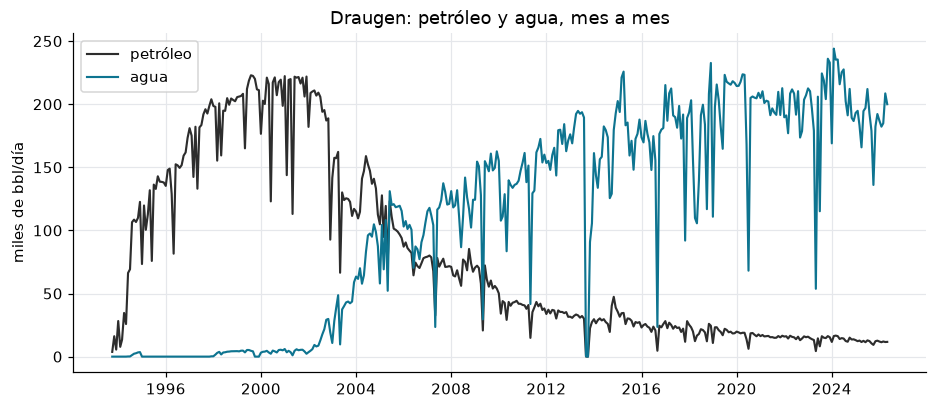

In [5]:
g = d[d.campo == "DRAUGEN"].sort_values("fecha")

fig, ax = plt.subplots()
ax.plot(g.fecha, g.oil_bpd / 1000, color=NEGRO_OIL, lw=1.4, label="petróleo")
ax.plot(g.fecha, g.agua_bpd / 1000, color=AZUL_AGUA, lw=1.4, label="agua")
ax.set_ylabel("miles de bbl/día")
ax.set_title("Draugen: petróleo y agua, mes a mes")
ax.legend()
plt.show()

### 2.1 · ¿Vieron el salto?

El agua está **exactamente en cero** durante años, y de golpe pega un salto
vertical.

Un yacimiento **no hace eso**. El agua entra de a poco y sube de a poco. Un
salto vertical de 0 a decenas de miles de barriles en un mes no es física.

Vamos a mirar en qué fecha exacta pasa, y si le pasa a más campos.

In [6]:
# el primer mes con agua > 0 de cada campo que arranco antes de 1995
viejos = []
for c, g in d.groupby("campo"):
    g = g.sort_values("fecha")
    if g.fecha.min().year >= 1995:
        continue
    con_agua = g[g.agua_bpd > 0]
    viejos.append({"campo": c,
                   "arranco": g.fecha.min().year,
                   "primer_agua": con_agua.fecha.min().year if len(con_agua) else None})

viejos = pd.DataFrame(viejos)
print(f"campos que arrancaron antes de 1995: {len(viejos)}\n")
print("en que anio reportan su PRIMERA gota de agua:")
print(viejos.primer_agua.value_counts().sort_index().to_string())

campos que arrancaron antes de 1995: 28

en que anio reportan su PRIMERA gota de agua:
primer_agua
1994.0     1
1999.0     1
2000.0    19
2001.0     1


### 2.2 · Diecinueve campos distintos «estrenan» agua el mismo año

Campos de distintas edades, distintos operadores y distintas rocas no pueden
haber recibido el agua todos el mismo año. Eso no es un yacimiento: es un
**cambio en el reporte**.

Confirmémoslo contando de otra manera: cuántos campos estaban produciendo cada
año, y cuántos de ellos reportaban aunque fuera un barril de agua.

In [7]:
for anio in (1998, 1999, 2000, 2001):
    u = d[d.fecha.dt.year == anio]
    produciendo = (u.groupby("campo").oil_bpd.mean() > 100).sum()
    reportando  = (u.groupby("campo").agua_bpd.max() > 0).sum()
    print(f"{anio}:  produciendo {produciendo:>3}   |   reportando agua {reportando:>3}")

1998:  produciendo  35   |   reportando agua   1
1999:  produciendo  35   |   reportando agua   4
2000:  produciendo  35   |   reportando agua  37
2001:  produciendo  39   |   reportando agua  40


### 2.3 · El telón

En **1998** producían 35 campos y **uno solo** reportaba agua.
En **2000** producían los mismos 35 y la reportaban **todos**.

> **El agua no empezó en el año 2000. La obligación de reportarla empezó en el
> año 2000.**

Es un cambio regulatorio noruego, escondido en una columna de ceros que se ve
perfectamente normal. Si no lo hubiéramos mirado, el modelo habría aprendido
que *«el agua llega de golpe en enero»* — la historia del **regulador**, no la
del **yacimiento**.

**Lo que hacemos con esto:**

1. Ningún análisis del agua usa datos anteriores a enero de 2000. Los ceros de
   antes no son ceros: son ausencias.
2. A los campos que **ya venían con agua** cuando se levantó el telón los
   apartamos para el estudio de *cómo llega* el agua. Nunca les vimos la
   llegada, así que no pueden enseñárnosla.

In [8]:
TELON = pd.Timestamp(2000, 1, 1)     # antes de esta fecha, el agua no existe

print(f"filas totales:            {len(d):,}")
print(f"filas utiles para el agua: {(d.fecha >= TELON).sum():,}")

filas totales:            25,054
filas utiles para el agua: 20,330


### 2.4 · Y un detalle más: los meses negativos

El regulador a veces publica un mes con producción **negativa**. No es que el
campo haya absorbido petróleo: son ajustes contables, correcciones de meses
anteriores.

Son pocos, pero un valor negativo rompe cualquier cociente. `preparar_datos.py`
ya los puso en cero — lo verificamos.

In [9]:
print("meses con valores negativos que quedan en el archivo:")
print(f"  petroleo: {(d.oil_bpd < 0).sum()}")
print(f"  agua:     {(d.agua_bpd < 0).sum()}")
print(f"  gas:      {(d.gas_ksm3d < 0).sum()}")

meses con valores negativos que quedan en el archivo:
  petroleo: 0
  agua:     0
  gas:      0


## 3 · De barriles a señal: corte de agua, WOR y GOR

Los barriles solos no dicen mucho. Lo que dice cómo va un campo es la
**proporción**.

### 3.1 · El corte de agua

$$\text{corte de agua} = \frac{\text{barriles de agua}}
{\text{barriles de agua} + \text{barriles de petróleo}}$$

Si sale 0,75, de cada cuatro barriles que suben por el tubo tres son agua.

**Un detalle que parece menor y no lo es:** para el corte de un año no se
promedian los doce cortes mensuales. Se **suman los barriles** de todo el año y
se divide una sola vez. Un mes con la plataforma parada no puede pesar lo mismo
que un mes lleno.

In [10]:
def corte(g, i0, i1):
    '''Corte de agua AGREGADO de las filas [i0, i1) de un campo.

    Se suman barriles y se divide UNA vez -- no se promedian porcentajes.
    Devuelve NaN si el tramo pedido no existe o el campo no produjo nada.
    '''
    if i0 < 0 or i1 > len(g):
        return np.nan
    oil  = (g.oil_bpd  * g.dias).iloc[i0:i1].sum()      # bbl de petroleo
    agua = (g.agua_bpd * g.dias).iloc[i0:i1].sum()      # bbl de agua
    return agua / (agua + oil) if (agua + oil) > 0 else np.nan


# lo probamos con un campo que arranco despues del telon: le vemos todo
alv = d[d.campo == "ALVHEIM"].sort_values("fecha").reset_index(drop=True)
print(f"ALVHEIM arranco en {alv.fecha.min().year}")
print(f"corte del ultimo anio: {100*corte(alv, len(alv)-12, len(alv)):.1f} %")

ALVHEIM arranco en 2008
corte del ultimo anio: 74.8 %


### 3.2 · La curva en S

Grafiquemos el corte de Alvheim a lo largo de toda su vida. Casi todos los
campos recorren la misma forma:

1. **Plana y baja** — el agua todavía no llegó.
2. **La subida** — llegó el *breakthrough* y el corte trepa rápido.
3. **Plana y alta** — arriba del 85–90 % se aplana sola: ya queda poco petróleo
   por desplazar.

La etapa 2 es la que le interesa a esta clase, porque es la única donde todavía
hay tiempo de hacer algo.

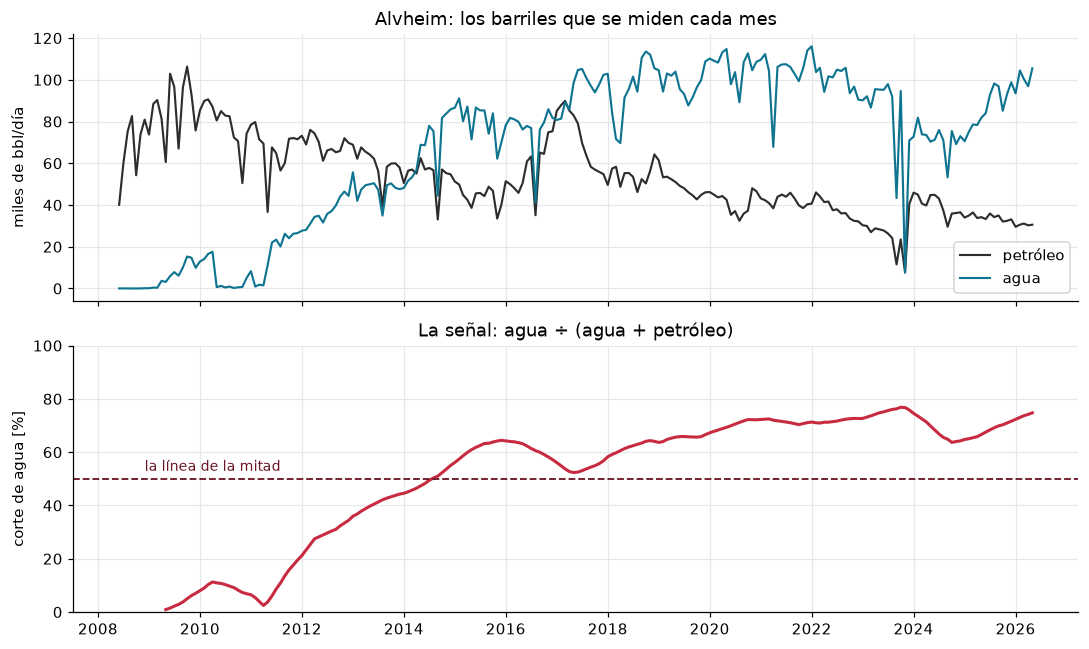

In [11]:
# corte mes a mes, calculado sobre una ventana movil de 12 meses
def corte_movil(g, ventana=12):
    num = (g.agua_bpd * g.dias).rolling(ventana).sum()
    den = ((g.agua_bpd + g.oil_bpd) * g.dias).rolling(ventana).sum()
    return 100 * num / den


fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

a1.plot(alv.fecha, alv.oil_bpd / 1000, color=NEGRO_OIL, lw=1.4, label="petróleo")
a1.plot(alv.fecha, alv.agua_bpd / 1000, color=AZUL_AGUA, lw=1.4, label="agua")
a1.set_ylabel("miles de bbl/día")
a1.set_title("Alvheim: los barriles que se miden cada mes")
a1.legend()

a2.plot(alv.fecha, corte_movil(alv), color=ROJO, lw=2)
a2.axhline(50, color="#6B1525", ls="--", lw=1.2)
a2.text(alv.fecha.iloc[6], 53, "la línea de la mitad", fontsize=9, color="#6B1525")
a2.set_ylim(0, 100)
a2.set_ylabel("corte de agua [%]")
a2.set_title("La señal: agua ÷ (agua + petróleo)")
plt.tight_layout()
plt.show()

### 3.3 · Corte y WOR: la misma cosa en dos idiomas

El **WOR** (*water–oil ratio*) es agua ÷ petróleo, sin sumar el agua abajo.
Dice cuántos barriles de agua vienen por cada uno de petróleo.

$$\text{WOR} = \frac{\text{corte}}{1 - \text{corte}}$$

El corte va de 0 a 100 % y nunca se dispara: cómodo para graficar. El WOR crece
sin límite: exagera a propósito el final de la vida del campo, que es donde se
decide el abandono.

Los dos dicen lo mismo. Cuál usar depende de con quién esté uno hablando.

In [12]:
def wor(corte_):
    '''Convierte corte de agua (0 a 1) en WOR (bbl de agua por bbl de oil).'''
    return corte_ / (1 - corte_)


tabla = pd.DataFrame({"corte_%": [0, 50, 80, 90, 94, 98]})
tabla["WOR"] = [round(wor(c / 100), 1) for c in tabla["corte_%"]]
tabla["de cada 100 bbl, agua"] = tabla["corte_%"]
print(tabla.to_string(index=False))
print()

dra = d[d.campo == "DRAUGEN"].sort_values("fecha").reset_index(drop=True)
c_dra = corte(dra, len(dra) - 12, len(dra))
print(f"DRAUGEN hoy: corte {100*c_dra:.0f} %  ->  WOR {wor(c_dra):.0f}")
print("es decir, 16 barriles de agua por cada uno de petroleo.")

 corte_%  WOR  de cada 100 bbl, agua
       0  0.0                      0
      50  1.0                     50
      80  4.0                     80
      90  9.0                     90
      94 15.7                     94
      98 49.0                     98

DRAUGEN hoy: corte 94 %  ->  WOR 16
es decir, 16 barriles de agua por cada uno de petroleo.


Fíjense en el salto: entre 94 % y 98 % de corte hay solo **cuatro puntos**,
pero el WOR se **triplica** (de 16 a 49). Los últimos puntos de corte son los
que de verdad duelen.

Por eso el resto de la clase trabaja en **corte** y no en WOR: está acotado
entre 0 y 100, y así ningún campo viejo domina todo el error. Es una decisión
de método, y la decimos en voz alta.

### 3.4 · El GOR: la otra señal

El **GOR** (*gas–oil ratio*) es cuánto gas viene con cada barril de petróleo.

Bajo tierra el petróleo tiene gas **disuelto** adentro, como una gaseosa
cerrada. Mientras la presión sea alta, el gas se queda ahí. Cuando la presión
cae por debajo de la **presión de burbuja**, el gas se libera *dentro de la
roca* — y una vez libre se mueve mucho más rápido que el petróleo, así que se
escapa hacia el pozo dejando atrás el crudo que debía empujar.

**Un GOR que sube es casi siempre el aviso de que el yacimiento está perdiendo
presión.** Casi siempre, porque hay una excepción grande: si el operador está
*inyectando* gas, el GOR sube por otra razón. Vamos a chocar con eso al final.

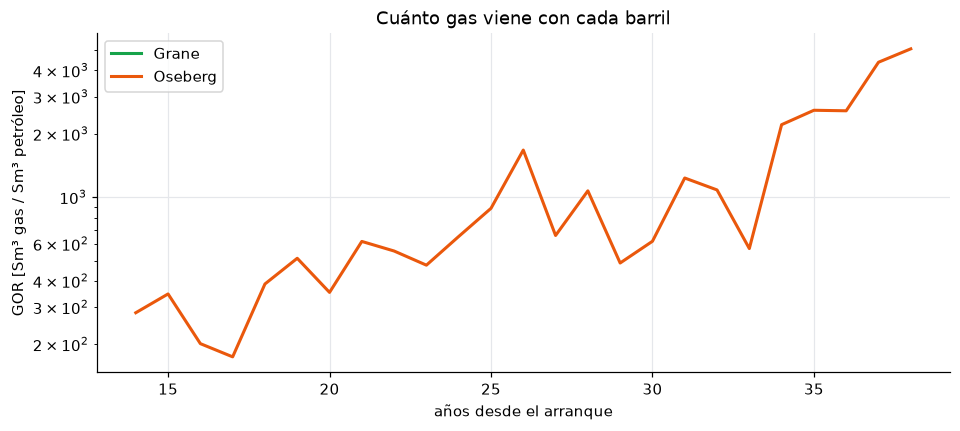

In [13]:
BBL = 6.2898     # barriles en un metro cubico estandar


def gor(g, i0, i1):
    '''GOR agregado del tramo, en Sm3 de gas por Sm3 de petroleo.'''
    if i0 < 0 or i1 > len(g):
        return np.nan
    oil = (g.oil_bpd / BBL * g.dias).iloc[i0:i1].sum()      # Sm3
    gas = (g.gas_ksm3d * 1e3 * g.dias).iloc[i0:i1].sum()    # Sm3
    return gas / oil if oil > 0 else np.nan


fig, ax = plt.subplots()
for campo, color in [("GRANE", VERDE), ("OSEBERG", NARANJA)]:
    g = d[d.campo == campo].sort_values("fecha").reset_index(drop=True)
    anios = range(2, len(g) // 12)
    vals = [(a, gor(g, 12 * a, 12 * (a + 1))) for a in anios]
    vals = [(a, v) for a, v in vals if v and v > 0]
    ax.plot([a for a, _ in vals], [v for _, v in vals], color=color, lw=2,
            label=campo.title())
ax.set_yscale("log")
ax.set_xlabel("años desde el arranque")
ax.set_ylabel("GOR [Sm³ gas / Sm³ petróleo]")
ax.set_title("Cuánto gas viene con cada barril")
ax.legend()
plt.show()

## 4 · El reloj del agua

Para comparar campos hay que alinearlos. En la Clase 3 los alineamos desde su
**pico de producción**. Acá los alineamos desde el mes en que **les llegó el
agua**, porque la historia del agua empieza ese día.

### 4.1 · Cómo definimos «llegó»

> El agua llegó el primer mes en que el corte pasó de **2 %** y se mantuvo
> arriba **tres meses seguidos**.

Los dos números tienen razón de ser, y los dos son discutibles. El **2 %**
separa el agua de verdad del ruido de medición. El **sostenido tres meses**
evita que un mes raro —una prueba, una parada— dispare la fecha.

Es la misma lógica del suavizado con el que buscamos el pico en la Clase 3: una
fecha importante no se decide con un solo mes.

In [14]:
UMBRAL_AGUA = 0.02        # 2 % de corte mensual
SOSTENIDO = 3             # meses seguidos


def llegada_agua(g):
    '''Indice de la fila en que llego el agua. None si nunca llego.

    Solo se busca DESPUES del telon: antes de 2000 la columna esta vacia.
    '''
    wc = g.agua_bpd / (g.agua_bpd + g.oil_bpd).replace(0, np.nan)
    wc[g.fecha < TELON] = np.nan
    con = (wc > UMBRAL_AGUA).rolling(SOSTENIDO).sum() == SOSTENIDO
    return int(con.idxmax()) if con.any() else None


def censurado(g):
    '''True si al campo NO le vimos llegar el agua.

    Son los campos que ya producian antes del 2000 y que, cuando el regulador
    empezo a contar, ya venian con agua. Su 'llegada' seria un invento del
    reporte, no del yacimiento.
    '''
    if g.fecha.min() >= TELON - pd.DateOffset(months=6):
        return False
    ia = llegada_agua(g)
    return ia is None or g.fecha.iloc[ia] < TELON + pd.DateOffset(months=18)


campos = {c: g.sort_values("fecha").reset_index(drop=True)
          for c, g in d.groupby("campo")}

n_cens = sum(1 for g in campos.values() if censurado(g))
print(f"campos totales:                       {len(campos)}")
print(f"campos censurados (ya venian con agua): {n_cens}")

campos totales:                       107
campos censurados (ya venian con agua): 38


### 4.2 · El nido y el orden

A la izquierda, todas las trayectorias por calendario: un nido imposible de
leer. A la derecha, las mismas alineadas por el reloj del agua.

campos con curva de agua completa: 45


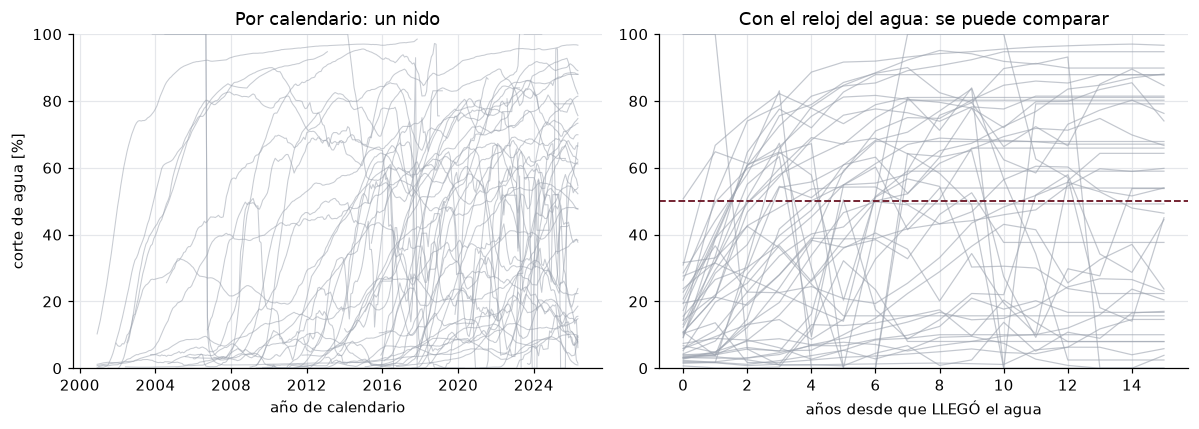

In [15]:
def curvas_familia(campos):
    '''Para cada campo con >= 6 anios de agua: su corte anual desde que el
    agua llego (anios 0..15). Los anios que aun no vivio se rellenan con el
    ultimo valor observado.'''
    curvas = {}
    for c, g in campos.items():
        if censurado(g):
            continue
        ia = llegada_agua(g)
        if ia is None:
            continue
        ys = np.array([corte(g, ia + 12 * a, ia + 12 * (a + 1))
                       for a in range(16)], float)
        if np.isfinite(ys).sum() < 6:
            continue
        ult = np.nanmax(np.where(np.isfinite(ys))[0])
        for j in range(len(ys)):
            if not np.isfinite(ys[j]):
                ys[j] = ys[ult] if j > ult else 0.0
        curvas[c] = ys
    return curvas


curvas = curvas_familia(campos)
print(f"campos con curva de agua completa: {len(curvas)}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for c in curvas:
    g = campos[c]
    v = g[g.fecha >= TELON]
    a1.plot(v.fecha, corte_movil(v), color=GRIS, lw=0.7, alpha=.55)
a1.set_ylim(0, 100)
a1.set_ylabel("corte de agua [%]")
a1.set_xlabel("año de calendario")
a1.set_title("Por calendario: un nido")

for c, ys in curvas.items():
    a2.plot(np.arange(16), 100 * ys, color=GRIS, lw=0.8, alpha=.6)
a2.axhline(50, color="#6B1525", ls="--", lw=1.2)
a2.set_ylim(0, 100)
a2.set_xlabel("años desde que LLEGÓ el agua")
a2.set_title("Con el reloj del agua: se puede comparar")
plt.tight_layout()
plt.show()

## 5 · ¿Todos los campos envejecen igual? — K-means

Ahora tenemos 45 curvas alineadas. Aparece una pregunta que el dato puede
contestar y nosotros no: ¿esas curvas se parecen entre sí de alguna manera
sistemática, o cada campo es un mundo?

**El problema: no hay respuesta correcta.** Nadie etiquetó estas curvas. No
existe una columna que diga «este campo es de conificación» — eso se sabría
perforando. Cuando no hay respuesta que aprender, no se puede *supervisar* al
modelo. Hay que pedirle otra cosa: que **ordene**.

### 5.1 · Qué hace K-means, en cuatro pasos

Salió en el Módulo 4, y como acá nada se da por sabido, lo volvemos a armar:

1. Uno decide cuántos grupos quiere. Digamos **tres**.
2. El método inventa **tres curvas promedio** cualquiera.
3. A cada campo le asigna la curva promedio a la que **más se parece**.
4. Recalcula cada curva promedio con los campos que le tocaron, y vuelve al 3.

Se repite hasta que nadie se cambia de grupo. A esas curvas promedio se les
dice **centroides**.

**Dos advertencias antes de usarlo:**

- **El 3 lo elegimos nosotros.** K-means no descubre cuántos grupos hay. Si le
  pedimos 8, nos da 8 — aunque no signifiquen nada. Elegimos 3 porque es lo que
  se puede explicar en una reunión.
- **Siempre devuelve grupos.** Aunque los datos sean puro ruido, K-means
  devuelve tres grupos prolijos. Que existan **no prueba que signifiquen algo**.
  Por eso más adelante los vamos a someter a un examen.

Y una diferencia con el Módulo 4: allá agrupamos **filas de una tabla**. Acá
cada cosa que agrupamos es una **curva entera** — 16 números, uno por año de
vida con agua. Se parecen dos campos cuando sus dieciséis números se parecen.

In [16]:
K = 3
nombres = sorted(curvas)
M = np.array([curvas[c] for c in nombres])     # 45 filas x 16 columnas

km = KMeans(K, n_init=20, random_state=0).fit(M)

# ordenamos los grupos por su corte a los 8 anios, para que el 0 sea el mas
# lento y el 2 el mas bravo -- si no, el numero que asigna K-means es azaroso
orden = np.argsort(km.cluster_centers_[:, 8])
etiqueta = {int(f): r for r, f in enumerate(orden)}
asignacion = {nombres[i]: etiqueta[int(km.labels_[i])] for i in range(len(nombres))}
centros = km.cluster_centers_[orden]

NOMBRES_FAM = ["LENTA", "MEDIA", "BRAVA"]
COL_FAM = [VERDE, "#D97706", ROJO]

for f in range(K):
    n = sum(1 for c in asignacion if asignacion[c] == f)
    cruce = np.where(100 * centros[f] >= 50)[0]
    cuando = f"{cruce[0]} años" if len(cruce) else "no llega en 15 años"
    print(f"{NOMBRES_FAM[f]:6s} n={n:2d} | corte a 5 anios de agua "
          f"{100*centros[f][5]:3.0f} % | cruza 50 %: {cuando}")

LENTA  n=12 | corte a 5 anios de agua   8 % | cruza 50 %: no llega en 15 años
MEDIA  n=13 | corte a 5 anios de agua  30 % | cruza 50 %: no llega en 15 años
BRAVA  n=20 | corte a 5 anios de agua  67 % | cruza 50 %: 3 años


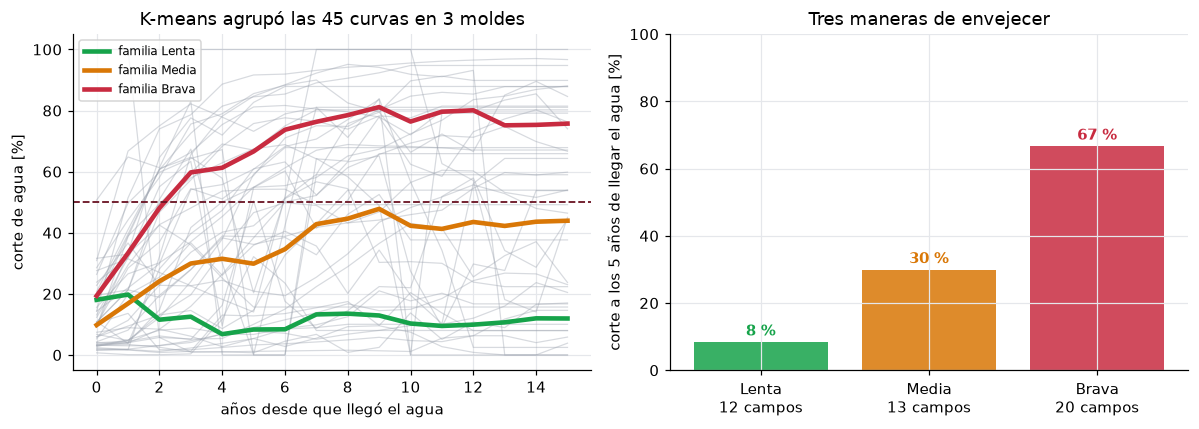

In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

for ys in M:
    a1.plot(np.arange(16), 100 * ys, color=GRIS, lw=0.8, alpha=.4)
for f in range(K):
    a1.plot(np.arange(16), 100 * centros[f], color=COL_FAM[f], lw=3,
            label=f"familia {NOMBRES_FAM[f].title()}")
a1.axhline(50, color="#6B1525", ls="--", lw=1.2)
a1.set_xlabel("años desde que llegó el agua")
a1.set_ylabel("corte de agua [%]")
a1.set_title("K-means agrupó las 45 curvas en 3 moldes")
a1.legend(fontsize=8)

conteo = [sum(1 for c in asignacion if asignacion[c] == f) for f in range(K)]
a2.bar(range(K), [100 * centros[f][5] for f in range(K)], color=COL_FAM, alpha=.85)
for f in range(K):
    a2.text(f, 100 * centros[f][5] + 2, f"{100*centros[f][5]:.0f} %",
            ha="center", fontweight="bold", color=COL_FAM[f])
a2.set_xticks(range(K))
a2.set_xticklabels([f"{NOMBRES_FAM[f].title()}\n{conteo[f]} campos" for f in range(K)])
a2.set_ylim(0, 100)
a2.set_ylabel("corte a los 5 años de llegar el agua [%]")
a2.set_title("Tres maneras de envejecer")
plt.tight_layout()
plt.show()

### 5.2 · Los nombres los pusimos nosotros

El método devuelve «grupo 0, 1 y 2». Nada más. *Lenta*, *Media* y *Brava*
salieron de mirar las tres curvas y ponerles una palabra que se pueda usar en
una reunión.

**Ese paso no es del método: es de ustedes.** Y es donde entra el conocimiento
de yacimiento. Un grupo sin nombre es un número en una columna; un grupo con
nombre es algo que se puede defender frente a un gerente.

Veamos quién es quién.

In [18]:
for f in range(K):
    miembros = sorted(c for c in nombres if asignacion[c] == f)
    print(f"\n{NOMBRES_FAM[f]} ({len(miembros)} campos):")
    print("   " + ", ".join(m.title() for m in miembros))


LENTA (12 campos):
   Alve, Embla, Fram H-Nord, Kvitebjørn, Maria, Mikkel, Morvin, Skarv, Tambar, Utgard, Vega, Åsgard

MEDIA (13 campos):
   Byrding, Fram, Gjøa, Goliat, Grane, Gudrun, Kristin, Oseberg Sør, Rev, Tune, Tyrihans, Valemon, Visund Sør

BRAVA (20 campos):
   Alvheim, Bøyla, Edvard Grieg, Gimle, Glitne, Huldra, Ivar Aasen, Jotun, Knarr, Oseberg Øst, Ringhorne Øst, Sigyn, Skirne, Skuld, Svalin, Sygna, Urd, Vilje, Volund, Volve


## 6 · El encargo: ¿dónde está este campo en cinco años?

Nos paramos en **Oseberg, enero de 2013**. Va en 35 % de corte. Tapamos lo que
pasó después y pronosticamos dónde estará en **2018**.

### 6.1 · Por qué cinco años

No es un capricho: es lo que tarda una ampliación de planta de agua entre el
estudio, la aprobación del presupuesto y el arranque. Si el pronóstico llega
con un año de anticipación, ya no sirve — la decisión hay que tomarla antes.

> **El horizonte de un pronóstico lo fija la decisión, nunca el modelo.**

### 6.2 · Cómo se arma un examen honesto

Un campo no alcanza para decir qué método es mejor: sería una anécdota.
Necesitamos muchos exámenes.

1. Nos paramos en un **enero** cualquiera, de un campo cualquiera.
2. Miramos **solo hacia atrás**: los dos últimos años de corte, y lo que se
   sepa del campo hasta esa fecha.
3. El corte **cinco años después** es la respuesta correcta. Existe —porque ya
   pasó— pero el método no la ve.
4. Repetimos para cada campo y cada año en que se pueda.

In [19]:
HIST = 4 * 12          # meses de historia que exigimos antes de examinar
H = 5 * 12             # el horizonte: 5 anios
CRUCE = 0.50           # la linea que decide la clase


def examenes(campos, h=H):
    '''Una fila por examen: lo que se sabia, y la respuesta correcta.'''
    filas = []
    for c, g in campos.items():
        oil_acum = (g.oil_bpd * g.dias).cumsum()
        i_agua = llegada_agua(g)
        for t in range(HIST, len(g) - h):
            if g.fecha.iloc[t].month != 1:              # un examen por enero
                continue
            # el telon: los dos anios de historia que mira el examen tienen
            # que estar despues de que el regulador empezara a contar el agua
            if g.fecha.iloc[t - 24] < TELON:
                continue
            wc_hoy = corte(g, t - 12, t)
            wc_ayer = corte(g, t - 24, t - 12)
            wc_fut = corte(g, t + h - 12, t + h)
            if any(np.isnan(v) for v in (wc_hoy, wc_ayer, wc_fut)):
                continue
            pico = g.oil_bpd.iloc[:t].max()
            if pico <= 0:
                continue
            # ¿cruzo la mitad en ALGUN anio del horizonte?
            anuales = [corte(g, t + k - 12, t + k) for k in range(12, h + 1, 12)]
            anuales = [v for v in anuales if not np.isnan(v)]
            oil_hoy = g.oil_bpd.iloc[t - 12:t].mean()
            filas.append(dict(
                campo=c, t=t, anio=g.fecha.iloc[t].year,
                wc_hoy=wc_hoy, pend=wc_hoy - wc_ayer,
                edad_agua=(t - i_agua) / 12 if i_agua is not None and t > i_agua else 0.0,
                frac_decl=oil_hoy / pico, log_pico=np.log10(pico),
                log_np=np.log10(max(oil_acum.iloc[t - 1], 1.0)), meses=t,
                oil_hoy=oil_hoy,
                gor_hoy=gor(g, t - 12, t), gor_ayer=gor(g, t - 24, t - 12),
                gor_fut=gor(g, t + h - 12, t + h),
                wc_fut=wc_fut,
                wc_max=max(anuales) if anuales else np.nan))
    return pd.DataFrame(filas)


s = examenes(campos)
print(f"examenes: {len(s)}")
print(f"campos:   {s.campo.nunique()}")
print(f"anios:    {s.anio.min()} a {s.anio.max()}")
s[["campo", "anio", "wc_hoy", "pend", "wc_fut"]].head()

examenes: 885
campos:   73
anios:    2002 a 2021


,campo,anio,wc_hoy,pend,wc_fut
0,ALVE,2013,0.001068,-0.004646,0.066781
1,ALVE,2014,0.015523,0.014454,0.148413
2,ALVE,2015,0.024941,0.009419,0.132193
3,ALVE,2016,0.009260,-0.015681,0.151039
4,ALVE,2017,0.010074,0.000814,0.160947


### 6.3 · El detalle que arruina a mucha gente

El mismo campo aparece en **varios** exámenes: Oseberg está en 2005, 2006,
2007… Y los exámenes de un mismo campo se parecen muchísimo entre sí — son la
misma historia corrida un año.

> Si dejamos un examen de Oseberg en entrenamiento y otro en prueba, el modelo
> ya vio la respuesta casi entera. El resultado sale bárbaro **en el papel**, y
> después falla en el campo nuevo, que es justo para lo que se compró.

Por eso lo que se deja afuera es el **campo entero**, con todos sus años. En
`scikit-learn` eso es `GroupKFold`, con el nombre del campo como grupo — la
misma herramienta de la Clase 2, y la versión general de lo que hicimos a mano
en la Clase 3.

In [20]:
print("cuantos examenes aporta cada campo (los 8 primeros):")
print(s.campo.value_counts().head(8).to_string())

cuantos examenes aporta cada campo (los 8 primeros):
campo
BRAGE       20
DRAUGEN     20
EKOFISK     20
ELDFISK     20
EMBLA       20
GULLFAKS    20
HEIDRUN     20
HOD         20


## 7 · Los cuatro que van a competir

Como en toda clase de este módulo: primero el **récord a batir**. Si nada le
gana, el problema estaba mal planteado.

| # | método | qué hace |
|---|---|---|
| 1 | **«El agua sigue igual»** | el corte de dentro de 5 años es el de hoy. Cero cálculo |
| 2 | **Su propia tendencia** | subió 3 puntos este año → subirá 15 en cinco |
| 3 | **Análogos de la flota** | busco otros campos que estaban en un corte parecido, miro dónde terminaron, tomo la mediana |
| 4 | **Bosque de flota** | un Random Forest que mira ocho datos a la vez |

Los dos primeros solo miran el campo de uno. Los dos últimos aprenden de
**campos que ya recorrieron el camino**.

**Un detalle de diseño del bosque:** no le pedimos el corte futuro, sino
**cuánto va a subir**. Predecir el cambio en vez del nivel le evita reaprender
en cada árbol algo que ya sabemos.

In [21]:
def rivales(s, h=H):
    '''Agrega una columna por metodo. Todos honestos: ninguno ve el futuro
    ni el campo que esta prediciendo.'''
    s = s.copy()

    # 1 y 2: solo miran el campo de uno
    s["persistencia"] = s.wc_hoy
    s["tendencia"] = (s.wc_hoy + s.pend * h / 12).clip(0, 0.99)

    # 3: analogos -- entre los examenes de OTROS campos con corte parecido
    # hoy (+-5 puntos), ¿en que corte terminaron? mediana y banda P10-P90
    med, lo, hi = [], [], []
    wc_o, y_o, c_o = s.wc_hoy.values, s.wc_fut.values, s.campo.values
    for i in range(len(s)):
        m = (np.abs(wc_o - wc_o[i]) < 0.05) & (c_o != c_o[i])
        if m.sum() >= 8:
            med.append(np.median(y_o[m]))
            lo.append(np.quantile(y_o[m], 0.10))
            hi.append(np.quantile(y_o[m], 0.90))
        else:
            med.append(wc_o[i]); lo.append(np.nan); hi.append(np.nan)
    s["analogos"], s["banda_lo"], s["banda_hi"] = med, lo, hi

    # 4: el bosque, validado dejando CAMPOS ENTEROS afuera
    feats = ["wc_hoy", "pend", "edad_agua", "frac_decl", "log_pico",
             "log_np", "meses", "analogos"]
    X = s[feats].values
    y = (s.wc_fut - s.wc_hoy).values           # aprende el INCREMENTO
    oof = np.full(len(s), np.nan)
    for tr, te in GroupKFold(5).split(X, y, s.campo.values):
        rf = RandomForestRegressor(400, min_samples_leaf=20,
                                   random_state=0, n_jobs=-1)
        rf.fit(X[tr], y[tr])
        oof[te] = rf.predict(X[te])
    s["bosque"] = np.clip(s.wc_hoy.values + oof, 0, 0.99)
    return s, feats


s, FEATS = rivales(s)
print("listo: los cuatro pronosticos calculados para los", len(s), "examenes")

listo: los cuatro pronosticos calculados para los 885 examenes


### 7.1 · Antes del marcador: el defecto del rival simple

«El agua sigue igual» no se equivoca al azar: se equivoca **siempre para el
mismo lado**.

Y eso es **sesgo**, no ruido. La distinción de la Clase 3: un error que va
siempre en la misma dirección **no se compensa entre campos, se suma**. Si toda
la flota se planifica con este método, la planta se dimensiona chica en todos
los campos a la vez.

en el 77 % de los examenes el corte de 5 anios despues
fue MAS ALTO que el de hoy
error mediano de 'el agua sigue igual': -7 puntos


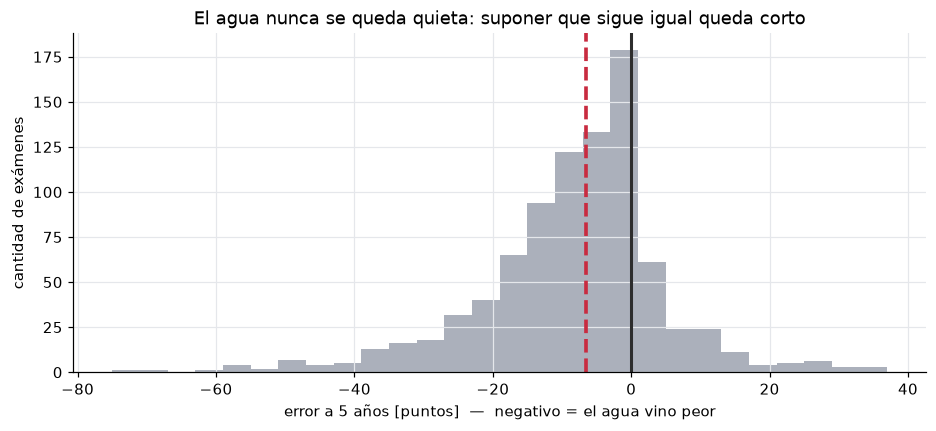

In [22]:
err = 100 * (s.persistencia - s.wc_fut)
subio = 100 * (s.wc_fut > s.wc_hoy).mean()

print(f"en el {subio:.0f} % de los examenes el corte de 5 anios despues")
print(f"fue MAS ALTO que el de hoy")
print(f"error mediano de 'el agua sigue igual': {err.median():+.0f} puntos")

fig, ax = plt.subplots()
ax.hist(err, bins=np.arange(-75, 40, 4), color=GRIS, alpha=.85)
ax.axvline(0, color=NEGRO_OIL, lw=2)
ax.axvline(err.median(), color=ROJO, lw=2.4, ls="--")
ax.set_xlabel("error a 5 años [puntos]  —  negativo = el agua vino peor")
ax.set_ylabel("cantidad de exámenes")
ax.set_title("El agua nunca se queda quieta: suponer que sigue igual queda corto")
plt.show()

### 7.2 · El marcador

In [23]:
MODELOS = [("El agua sigue igual", "persistencia"),
           ("Su propia tendencia", "tendencia"),
           ("Análogos de la flota", "analogos"),
           ("Bosque de flota", "bosque")]

print(f"{'metodo':>22} {'error tipico':>13} {'sesgo':>8}")
print("-" * 46)
for nom, col in MODELOS:
    e = 100 * (s[col] - s.wc_fut)
    print(f"{nom:>22} {e.abs().mean():11.1f} pp {e.mean():+7.1f} pp")

                metodo  error tipico    sesgo
----------------------------------------------
   El agua sigue igual        11.8 pp    -7.7 pp
   Su propia tendencia        18.6 pp    +1.6 pp
  Análogos de la flota         9.7 pp    +0.3 pp
       Bosque de flota         9.7 pp    -0.0 pp


### 7.3 · Dos cosas que dice ese marcador

1. **Extrapolar la recta de un solo campo a cinco años es una mala idea,
   medida.** Es el método más intuitivo de todos y quedó último. Un año bueno o
   malo se multiplica por cinco y se convierte en un disparate.

2. **Los dos de flota empatan entre sí.** Ocho variables y cuatrocientos
   árboles no le ganan a una mediana bien elegida.

Eso segundo es incómodo de decir en una clase de *machine learning*. Y es
exactamente por eso que lo decimos.

> **Lo que pagó no fue el algoritmo. Fue mirar a los otros campos.**

Los dos métodos que ganan tienen una sola cosa en común, y no es la
sofisticación: los dos aprenden de campos que ya recorrieron el camino. Es lo
que venimos midiendo desde la Clase 2 — el ML cobra cuando hay **muchas
unidades**.

**Consecuencia práctica:** si alguien les vende un modelo complicado, la
pregunta no es qué algoritmo usa. Es **contra qué lo comparó**.

### 7.4 · Oseberg: destapamos

In [24]:
fila = s[(s.campo == "OSEBERG") & (s.anio == 2013)].iloc[0]

print(f"OSEBERG, enero de 2013: va en {100*fila.wc_hoy:.0f} % de corte\n")
for nom, col in MODELOS:
    print(f"  {nom:>22}: {100*fila[col]:5.0f} %")
print(f"  {'banda P10-P90':>22}: {100*fila.banda_lo:.0f} a {100*fila.banda_hi:.0f} %")
print()
print(f"  {'LO QUE PASO EN 2018':>22}: {100*fila.wc_fut:5.0f} %   <-- cruzo la mitad")

OSEBERG, enero de 2013: va en 35 % de corte

     El agua sigue igual:    35 %
     Su propia tendencia:    34 %
    Análogos de la flota:    49 %
         Bosque de flota:    39 %
           banda P10-P90: 29 a 69 %

     LO QUE PASO EN 2018:    51 %   <-- cruzo la mitad


Los dos métodos que solo miraban a Oseberg dijeron que se quedaba donde estaba.
Los análogos dijeron 49 % — y la banda contuvo la respuesta.

Un solo campo no prueba nada: es una anécdota. Lo que prueba algo son los 885
exámenes. Pero ayuda a ver qué significan esos dos puntos de diferencia.

### 7.5 · La banda, otra vez — y otra vez cumple

En la Clase 3 construimos la banda así: en vez de quedarnos con la mediana de
los análogos, nos quedamos con el rango donde cayó el **80 % central** de los
casos parecidos — del percentil 10 al 90.

Y le hacemos la misma auditoría: de los 885 exámenes, **¿en cuántos la banda
contuvo de verdad la respuesta?** Es la única pregunta que importa de un
intervalo.

In [25]:
b = s.dropna(subset=["banda_lo", "banda_hi"])
dentro = ((b.wc_fut >= b.banda_lo) & (b.wc_fut <= b.banda_hi)).mean()
ancho = 100 * (b.banda_hi - b.banda_lo).mean()

print(f"la banda P10-P90 PROMETE contener la realidad el 80 % de las veces")
print(f"y la CONTIENE el {100*dentro:.0f} %   ({len(b)} examenes)")
print(f"ancho medio de la banda: {ancho:.0f} puntos de corte")

la banda P10-P90 PROMETE contener la realidad el 80 % de las veces
y la CONTIENE el 79 %   (885 examenes)
ancho medio de la banda: 31 puntos de corte


Es la **segunda vez** que este método cumple lo que promete, con otro dato y
otra variable. Que cumpla una vez puede ser suerte; que cumpla dos veces en
problemas distintos empieza a ser un método.

**31 puntos de ancho es mucho, y está bien.** A un campo que hoy va en 35 % le
decimos: «en cinco años va a estar entre 29 % y 69 %». Es incómodo de
presentar, y es la verdad. La alternativa no es una banda más angosta: es una
banda angosta que miente.

Y aunque sea ancha, **decide**: si toda la banda está por debajo del límite de
la planta, no hay nada que hacer. Si toda está por encima, hay que ampliar sí o
sí. Solo cuando el límite cae dentro de la banda hace falta estudiar más — y
ahí la banda ya hizo su trabajo.

### 7.6 · ¿A qué distancia vale la pena todo esto?

Corramos el mismo marcador a 1, 2, 3, 4 y 5 años. **Esta celda tarda un poco**
porque reconstruye los exámenes cinco veces.

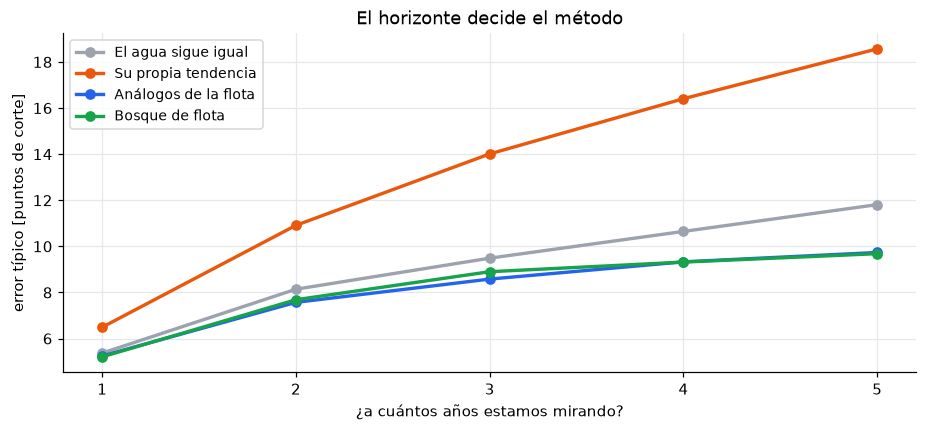

                 anios      1      2      3      4      5
   El agua sigue igual    5.4    8.1    9.5   10.6   11.8
   Su propia tendencia    6.5   10.9   14.0   16.4   18.6
  Análogos de la flota    5.2    7.6    8.6    9.3    9.7
       Bosque de flota    5.2    7.7    8.9    9.3    9.7


In [26]:
horizontes = [12, 24, 36, 48, 60]
res = {col: [] for _, col in MODELOS}

for h in horizontes:
    s_h, _ = rivales(examenes(campos, h), h)
    for _, col in MODELOS:
        res[col].append(100 * (s_h[col] - s_h.wc_fut).abs().mean())

fig, ax = plt.subplots()
for (nom, col), color in zip(MODELOS, [GRIS, NARANJA, "#2563EB", VERDE]):
    ax.plot(np.array(horizontes) / 12, res[col], "o-", color=color, lw=2.2,
            label=nom)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xlabel("¿a cuántos años estamos mirando?")
ax.set_ylabel("error típico [puntos de corte]")
ax.set_title("El horizonte decide el método")
ax.legend(fontsize=9)
plt.show()

print(f"{'anios':>22}" + "".join(f"{h//12:>7}" for h in horizontes))
for nom, col in MODELOS:
    print(f"{nom:>22}" + "".join(f"{v:7.1f}" for v in res[col]))

> **Antes de preguntar «¿qué modelo uso?», pregunten «¿a qué distancia estoy
> mirando?»**

A **un año** los cuatro están casi empatados: el agua no se mueve tanto, y
suponer que sigue igual es tan bueno como cualquier modelo. Si la decisión es a
un año —cuántos químicos comprar, cómo programar el mantenimiento—
**no monten nada de esto**. El corte de hoy alcanza, y cuesta cero.

Si la decisión es a cinco, la flota se paga sola.

### 7.7 · ¿En qué se fija el bosque?

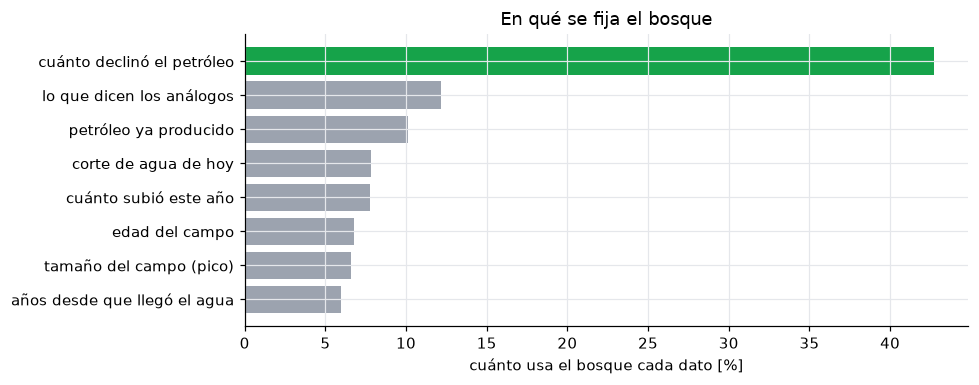

cuánto declinó el petróleo      42.7
lo que dicen los análogos       12.2
petróleo ya producido           10.1
corte de agua de hoy             7.8
cuánto subió este año            7.8
edad del campo                   6.8
tamaño del campo (pico)          6.6
años desde que llegó el agua     6.0


In [27]:
rf = RandomForestRegressor(400, min_samples_leaf=20, random_state=0, n_jobs=-1)
rf.fit(s[FEATS].values, (s.wc_fut - s.wc_hoy).values)

etiquetas = {
    "wc_hoy": "corte de agua de hoy", "pend": "cuánto subió este año",
    "edad_agua": "años desde que llegó el agua",
    "frac_decl": "cuánto declinó el petróleo",
    "log_pico": "tamaño del campo (pico)",
    "log_np": "petróleo ya producido", "meses": "edad del campo",
    "analogos": "lo que dicen los análogos"}

imp = pd.Series(100 * rf.feature_importances_,
                index=[etiquetas[f] for f in FEATS]).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(imp.index, imp.values, color=[VERDE if v == imp.max() else GRIS
                                      for v in imp.values])
ax.set_xlabel("cuánto usa el bosque cada dato [%]")
ax.set_title("En qué se fija el bosque")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(1).to_string())

**Lo que más mira no es el agua: es cuánto declinó el petróleo.** Puede
sorprender, pero acordémonos de qué le pedimos — no el corte futuro, sino
cuánto va a subir.

Un campo cuyo petróleo cayó a la mitad de su pico está más avanzado en su vida,
y al agua le queda menos camino por recorrer. Un campo que todavía produce
cerca de su pico tiene toda la subida por delante.

El modelo encontró solo algo que un ingeniero de yacimientos sabe: el agua y el
petróleo son dos caras del mismo balance.

> **Ojo con leer estas barras como causas.** Dicen *en qué se apoyó el modelo*,
> no *qué causa el agua*. Que se apoye en algo con sentido físico es una buena
> señal — no una demostración.

## 8 · El examen del agrupamiento

Volvamos a las tres familias. Tenemos moldes bonitos y con sentido físico. Es
tentador quedarse ahí — se ve bien en una lámina. Pero la regla del curso es
que **ninguna herramienta entra sin ganarse el puesto**.

> Si para pronosticar un campo me comparo solo con los de **su familia**, en
> vez de con toda la flota, ¿acierto más?

Y para que la prueba sea limpia, las familias se vuelven a construir **sin el
campo que estamos prediciendo**. Si no, ese campo ayudó a formar el molde con
el que después lo vamos a juzgar — y el examen estaría arreglado.

Es la misma precaución de la Clase 3: al que se examina, se lo saca del grupo.

**Antes de correr la celda: ¿qué apuestan?**

In [28]:
def examen_familias(campos, curvas, s):
    '''Compara analogos planos vs analogos de la misma familia.
    Para cada campo, las familias se reconstruyen SIN ese campo.
    '''
    res = []
    nombres = sorted(curvas)
    for cx in s.campo.unique():
        otros = [c for c in nombres if c != cx]
        if len(otros) < 10:
            continue
        Mo = np.array([curvas[c] for c in otros])
        km = KMeans(3, n_init=10, random_state=0).fit(Mo)
        lab = dict(zip(otros, km.labels_))

        g = campos[cx]
        ia = llegada_agua(g)
        for _, row in s[s.campo == cx].iterrows():
            t = int(row.t)
            # ¿a que molde se parece la curva PARCIAL de X hasta hoy?
            fam = None
            if ia is not None and t > ia + 12:
                span = min(int((t - ia) / 12), 15)
                parcial = np.array([corte(g, ia + 12 * a, ia + 12 * (a + 1))
                                    for a in range(span)])
                ok = np.isfinite(parcial)
                if ok.sum() >= 2:
                    dist = [np.nanmean((parcial[ok]
                            - km.cluster_centers_[f][:span][ok]) ** 2)
                            for f in range(3)]
                    fam = int(np.argmin(dist))

            pool = s[s.campo != cx]
            cerca = pool[np.abs(pool.wc_hoy - row.wc_hoy) < 0.05]
            cerca_f = (cerca[cerca.campo.isin([c for c in otros if lab[c] == fam])]
                       if fam is not None else cerca)

            fila = dict(campo=cx, wc_fut=row.wc_fut, fam=fam)
            for et, cc in [("plano", cerca), ("familia", cerca_f)]:
                if len(cc) >= 8:
                    fila[f"med_{et}"] = cc.wc_fut.median()
                    fila[f"lo_{et}"] = cc.wc_fut.quantile(0.10)
                    fila[f"hi_{et}"] = cc.wc_fut.quantile(0.90)
            res.append(fila)
    r = pd.DataFrame(res).dropna(subset=["med_plano", "med_familia"])
    return r[r.fam.notna()]


rfam = examen_familias(campos, curvas, s)
print(f"examenes evaluables: {len(rfam)}\n")

for et in ("plano", "familia"):
    e = 100 * (rfam[f"med_{et}"] - rfam.wc_fut)
    cob = 100 * ((rfam.wc_fut >= rfam[f"lo_{et}"]) &
                 (rfam.wc_fut <= rfam[f"hi_{et}"])).mean()
    anc = 100 * (rfam[f"hi_{et}"] - rfam[f"lo_{et}"]).mean()
    nombre = "toda la flota" if et == "plano" else "solo tu familia"
    print(f"analogos de {nombre:16s}: error {e.abs().mean():5.1f} pp | "
          f"banda ancho {anc:4.0f} pp, cumple {cob:3.0f} % (promete 80)")

examenes evaluables: 678

analogos de toda la flota   : error   9.0 pp | banda ancho   31 pp, cumple  81 % (promete 80)
analogos de solo tu familia : error  10.0 pp | banda ancho   30 pp, cumple  66 % (promete 80)


### 8.1 · El resultado: no. Y es una buena noticia

Comparándose solo con su familia el error **empeora**, y —peor todavía— la
banda se angosta pero **deja de cumplir**.

Al quedarse solo con los campos de la misma familia quedan menos casos con qué
comparar. Con menos casos, los extremos P10 y P90 se calculan con menos
información, y la banda **parece** más precisa.

> **Parece más precisa y es más frágil. Es el peor de los dos errores
> posibles.**

Una banda ancha que cumple le dice al gerente «no sé tanto como quisiera». Una
banda angosta que no cumple le dice «sé exactamente» — y le miente.

**¿Por qué no ayudó la familia?** Porque el corte de agua de hoy ya trae
adentro la historia del campo. Si un campo va en 60 % a los cinco años, eso ya
dice que fue rápido. La familia repite información que el número de hoy ya
tenía.

### 8.2 · Entonces, ¿para qué sirvió?

| No sirvió para | Sí sirvió para |
|---|---|
| Pronosticar mejor el número | **Describir** la flota: hay tres comportamientos, no ochenta |
| Angostar la banda sin romperla | **Elegir con quién comparar** un campo nuevo, del que casi no hay historia |
| | **Detectar al raro**: un campo que se salió de su molde es una pregunta de ingeniería |

> **La lección general del no supervisado: es una herramienta de diagnóstico,
> no de pronóstico.** Sirve para *entender* el conjunto, no para adivinar el
> próximo número.

## 9 · ¿A quién vigilo? — de un pronóstico a una lista

Hasta acá pedimos un **número**. Pero la otra decisión —a cuáles campos les
dedico la gente que tengo— no necesita un número: necesita una **lista
ordenada**.

> Tengo presupuesto para vigilar de cerca **diez** campos. ¿Cuáles diez?

Y eso cambia la manera de calificar. Ya no es el error en puntos: es **cuántos
de los diez que elegí de verdad cruzaron** la línea de la mitad.

Esto es lo mismo que nos pasó en la Clase 2 con la alarma. **Es fácil calcular
la métrica que el modelo devuelve; es más trabajo calcular la que la decisión
necesita** — y casi siempre son distintas.

In [29]:
# solo los campos que HOY estan debajo de la mitad: los que ya cruzaron no
# son candidatos a cruzar
ev = s[s.wc_hoy < CRUCE].copy()
ev["cruzo"] = ev.wc_max >= CRUCE

print(f"candidatos: {len(ev)}")
print(f"cruzaron:   {int(ev.cruzo.sum())}  ({100*ev.cruzo.mean():.0f} %)")

candidatos: 446
cruzaron:   148  (33 %)


In [30]:
# año por año, con presupuesto para 10 campos: ¿cuantos aciertos compra
# cada metodo? se calcula por cohorte anual y se promedia
aciertos = {"persistencia": [], "bosque": []}
cohortes = 0
for anio, ga in ev.groupby("anio"):
    if len(ga) < 15 or ga.cruzo.sum() < 2:
        continue
    cohortes += 1
    for m in aciertos:
        aciertos[m].append(int(ga.nlargest(10, m).cruzo.sum()))

print(f"cohortes anuales evaluadas: {cohortes}\n")
print(f"  vigilar a los mas cercanos al cruce: {np.mean(aciertos['persistencia']):.1f} de 10")
print(f"  vigilar a los que senala el bosque:  {np.mean(aciertos['bosque']):.1f} de 10")

cohortes anuales evaluadas: 20

  vigilar a los mas cercanos al cruce: 5.8 de 10
  vigilar a los que senala el bosque:  5.9 de 10


### 9.1 · Empatan

Con presupuesto para diez campos, el método más tonto de todos —ordenar por
quién está más cerca de la línea— acierta prácticamente lo mismo que el bosque.

**Para *ordenar* una lista, el modelo complicado no aporta.** Para saber *en
qué número* termina cada campo —que es lo que dimensiona una planta— ahí sí
gana la flota.

Contémoslo de otra forma, que es la manera honesta de comparar dos listas: se
toman **parejas** de campos, uno que sí cruzó y otro que no, y se le pregunta
al método cuál de los dos le preocupa más. **Acierta** si puso adelante al que
de verdad cruzó.

50 de cada 100 sería tirar una moneda. 100 sería perfecto.

In [31]:
from sklearn.metrics import roc_auc_score

lejos = ev[ev.wc_hoy < 0.30]        # los tranquilos de hoy

print("de cada 100 parejas, cuantas ordena bien:\n")
print(f"{'metodo':>28} {'todos':>8} {'tranquilos (<30 %)':>20}")
for nom, col in [("cercanía al cruce", "persistencia"), ("bosque de flota", "bosque")]:
    a = 100 * roc_auc_score(ev.cruzo, ev[col])
    b_ = 100 * roc_auc_score(lejos.cruzo, lejos[col])
    print(f"{nom:>28} {a:7.0f} {b_:19.0f}")

de cada 100 parejas, cuantas ordena bien:

                      metodo    todos   tranquilos (<30 %)
           cercanía al cruce      85                  67
             bosque de flota      85                  70


## 10 · El entregable: la lista de vigilancia de HOY

Todo lo anterior fue mirando hacia atrás, para poder calificarnos. Ahora lo
aplicamos a los campos **que están produciendo ahora**, con el dato de mayo de
2026.

El bosque se entrena con **todos** los exámenes históricos y califica la foto
de hoy.

In [32]:
def foto_de_hoy(campos, s):
    '''Los mismos rasgos que en los examenes, pero calculados sobre los
    ultimos meses del dato -- para los campos que siguen activos.'''
    filas = []
    for c, g in campos.items():
        if len(g) < HIST + 12:
            continue
        if (g.oil_bpd + g.agua_bpd).iloc[-12:].mean() <= 100:   # campo cerrado
            continue
        t = len(g)
        wc_hoy, wc_ayer = corte(g, t - 12, t), corte(g, t - 24, t - 12)
        if np.isnan(wc_hoy) or np.isnan(wc_ayer):
            continue
        ia = llegada_agua(g)
        pico = g.oil_bpd.max()
        oil_hoy = g.oil_bpd.iloc[-12:].mean()
        filas.append(dict(
            campo=c, wc_hoy=wc_hoy, pend=wc_hoy - wc_ayer,
            edad_agua=(t - ia) / 12 if ia is not None and t > ia else 0.0,
            frac_decl=oil_hoy / pico, log_pico=np.log10(pico),
            log_np=np.log10(max((g.oil_bpd * g.dias).sum(), 1.0)), meses=t,
            oil_hoy=oil_hoy, agua_hoy=g.agua_bpd.iloc[-12:].mean()))
    hoy = pd.DataFrame(filas)

    # los analogos de hoy salen del pool historico
    med, lo, hi = [], [], []
    for _, row in hoy.iterrows():
        m = s[(np.abs(s.wc_hoy - row.wc_hoy) < 0.05) & (s.campo != row.campo)]
        if len(m) >= 8:
            med.append(m.wc_fut.median())
            lo.append(m.wc_fut.quantile(0.10)); hi.append(m.wc_fut.quantile(0.90))
        else:
            med.append(row.wc_hoy); lo.append(np.nan); hi.append(np.nan)
    hoy["analogos"], hoy["banda_lo"], hoy["banda_hi"] = med, lo, hi
    return hoy


hoy = foto_de_hoy(campos, s)

rf_final = RandomForestRegressor(400, min_samples_leaf=20, random_state=0, n_jobs=-1)
rf_final.fit(s[FEATS].values, (s.wc_fut - s.wc_hoy).values)
hoy["bosque"] = np.clip(hoy.wc_hoy + rf_final.predict(hoy[FEATS].values), 0, 0.99)

# la lista: campos que aun no cruzaron y que valen la pena vigilar
lista = hoy[(hoy.wc_hoy < CRUCE) & (hoy.oil_hoy > 5000)].copy()
lista = lista.sort_values("bosque", ascending=False)

salida = lista[["campo", "wc_hoy", "pend", "bosque", "banda_lo", "banda_hi", "oil_hoy"]].copy()
for c in ["wc_hoy", "pend", "bosque", "banda_lo", "banda_hi"]:
    salida[c] = (100 * salida[c]).round(0)
salida["oil_hoy"] = (salida.oil_hoy / 1000).round(0)
salida.columns = ["campo", "corte hoy %", "subió %/año", "en 5 años %",
                  "P10 %", "P90 %", "mil bbl/d"]
print(f"candidatos: {len(lista)}\n")
print(salida.head(12).to_string(index=False))

candidatos: 16

         campo  corte hoy %  subió %/año  en 5 años %  P10 %  P90 %  mil bbl/d
JOHAN SVERDRUP         31.0         12.0         59.0   26.0   65.0      670.0
        GOLIAT         48.0         -6.0         55.0   30.0   72.0       22.0
          FRAM         48.0          2.0         48.0   30.0   72.0       13.0
       VALHALL         39.0          4.0         44.0   34.0   64.0       28.0
  GULLFAKS SØR         34.0         -5.0         44.0   30.0   70.0       20.0
           HOD         38.0          1.0         42.0   31.0   69.0        7.0
    KVITEBJØRN         38.0          3.0         41.0   34.0   64.0        5.0
       KRISTIN         24.0         -1.0         31.0   21.0   57.0        6.0
      TYRIHANS         22.0         -1.0         30.0   21.0   56.0        8.0
         SKARV         19.0          0.0         24.0   18.0   56.0       11.0
         NJORD         11.0        -11.0         24.0    8.0   54.0        8.0
         MARIA          8.0         

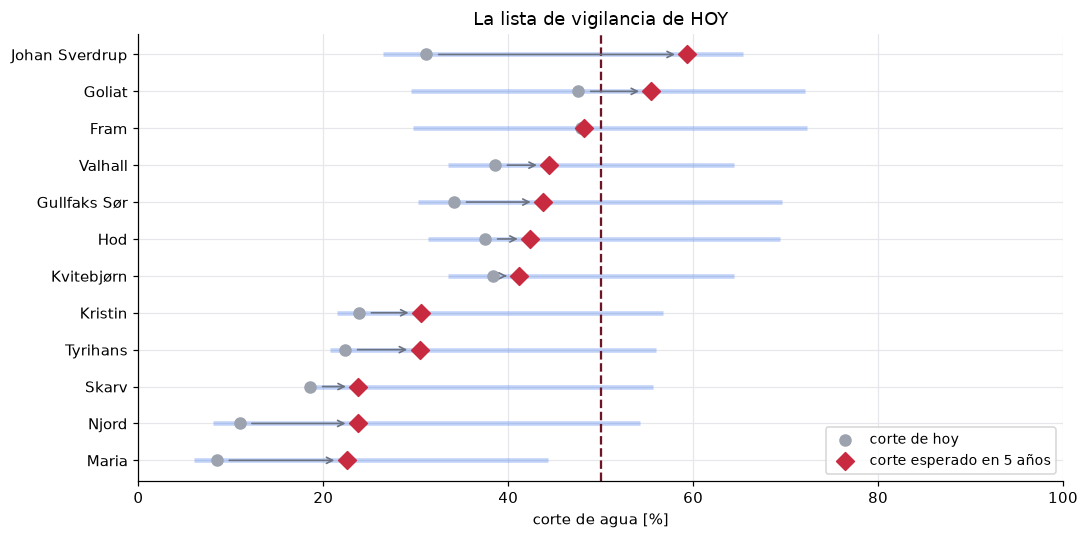

In [33]:
top = lista.head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(top))
for i, (_, row) in enumerate(top.iterrows()):
    if np.isfinite(row.banda_lo):
        ax.hlines(i, 100 * row.banda_lo, 100 * row.banda_hi,
                  color="#2563EB", lw=3, alpha=.28)
    ax.annotate("", xy=(100 * row.bosque - 1, i), xytext=(100 * row.wc_hoy + 1, i),
                arrowprops=dict(arrowstyle="->", color="#6B7280", lw=1.1))
ax.scatter(100 * top.wc_hoy, y, s=52, color=GRIS, zorder=3, label="corte de hoy")
ax.scatter(100 * top.bosque, y, s=68, color=ROJO, marker="D", zorder=4,
           label="corte esperado en 5 años")
ax.axvline(50, color="#6B1525", ls="--", lw=1.5)
ax.set_yticks(y)
ax.set_yticklabels([c.title() for c in top.campo])
ax.set_xlim(0, 100)
ax.set_xlabel("corte de agua [%]")
ax.set_title("La lista de vigilancia de HOY")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Lo que dice esa lista:**

- **Johan Sverdrup** la encabeza, y no es un campo cualquiera: es el más grande
  de Noruega. Va en 31 % de corte y viene subiendo fuerte.
- Campos como **Njord** y **María** van bajos y parecen tranquilos, pero el
  modelo los pone en la lista igual — porque su petróleo ya declinó mucho.
- Y las bandas son **anchas**. Ninguna de estas predicciones es una certeza, y
  así hay que presentarlas.

> Nadie sabe todavía si esto es correcto: la respuesta llega en 2031. Eso es lo
> que lo convierte en un pronóstico de verdad y no en un ejercicio de clase.

## 11 · ¿Y el gas? La misma receta, otro resultado

Corramos la misma maquinaria sobre el GOR. Trabajamos en logaritmo porque el
GOR se mueve en multiplicaciones, no en sumas: pasar de 100 a 200 es el mismo
«salto» que de 1.000 a 2.000.

Por eso el error se reporta como un **factor**: ×1,00 sería perfecto.

In [34]:
gg = s.dropna(subset=["gor_hoy", "gor_ayer", "gor_fut"])
gg = gg[(gg.gor_hoy > 0) & (gg.gor_ayer > 0) & (gg.gor_fut > 0)].copy()

lg_hoy, lg_fut = np.log10(gg.gor_hoy), np.log10(gg.gor_fut)

# analogos, igual que con el agua pero sobre el GOR
t3 = []
lo_, yo_, co_ = lg_hoy.values, lg_fut.values, gg.campo.values
for i in range(len(gg)):
    m = (np.abs(lo_ - lo_[i]) < 0.15) & (co_ != co_[i])
    t3.append(np.median(yo_[m]) if m.sum() >= 8 else lo_[i])

f_tonto = 10 ** (lg_hoy - lg_fut).abs().median()
f_anal = 10 ** pd.Series(np.abs(np.array(t3) - lg_fut.values)).median()
sube = 100 * (lg_fut > lg_hoy + np.log10(1.5)).mean()

print(f"examenes con GOR utilizable: {len(gg)}\n")
print(f"  'el GOR sigue igual':   error tipico  x{f_tonto:.2f}")
print(f"  analogos de la flota:   error tipico  x{f_anal:.2f}")
print()
print(f"y sin embargo: en el {sube:.0f} % de los examenes el GOR subio")
print("mas de una vez y media en cinco anios.")

examenes con GOR utilizable: 691

  'el GOR sigue igual':   error tipico  x1.46
  analogos de la flota:   error tipico  x1.37

y sin embargo: en el 33 % de los examenes el GOR subio
mas de una vez y media en cinco anios.


### 11.1 · Por qué el agua sí y el gas no

| El agua | El gas |
|---|---|
| Obedece a la **física del yacimiento**: un frente que avanza, una roca que lo deja pasar más rápido o más lento | Obedece además a **decisiones del operador**: inyectarlo para mantener presión, venderlo, reinyectarlo, quemarlo |
| Esa física **se parece entre campos**, así que la experiencia ajena sirve | Ninguna de esas decisiones está en el archivo público. El modelo no puede adivinarlas |

> **Lo decimos en voz alta: para el GOR, este método no está listo.** Haría
> falta saber qué está inyectando el operador cada mes.

Y aun así, vigilar el GOR sigue siendo obligatorio. Que no se pueda pronosticar
bien no quiere decir que no importe.

## 12 · Lo que vimos → lo que decidimos

| Lo que vimos | Lo que decidimos |
|---|---|
| El agua no se reportaba antes del 2000 | Ningún análisis usa datos anteriores; 38 campos apartados del estudio de llegada |
| Meses con producción negativa | Puestos en cero — son ajustes contables |
| Los campos no se pueden comparar por calendario | Alinear por **años desde que llegó el agua** |
| Hay tres formas de envejecer con el agua | Nombrarlas y usarlas para **describir**, no para pronosticar |
| Comparándose solo con su familia el error empeora y la banda deja de cumplir | **Descartar** el uso predictivo del agrupamiento |
| «El agua sigue igual» se queda corta en el 77 % de los casos | **No** usar persistencia para planificar capacidad |
| Extrapolar la tendencia propia es el peor método | **Descartarlo**, aunque sea el más intuitivo |
| Los análogos y el bosque empatan | Usar el **más simple de los dos** — la mediana de análogos |
| La banda P10–P90 cumple lo que promete | **Entregar siempre la banda**, no el punto |
| A 1 año todos empatan; a 5 la flota cobra | Montar esto **solo** para decisiones a varios años |
| Para ordenar la lista, la cercanía al cruce empata con el bosque | Usar el criterio simple para **priorizar**, el de flota para **dimensionar** |
| El GOR no mejora con esta receta | **Declararlo** y no entregar pronóstico de GOR |

### Los tres resultados negativos de hoy

Un buen análisis se reconoce por lo que descarta. Hoy descartamos tres cosas:

1. **Las familias no mejoran el pronóstico** — la banda por familia cumple
   mucho menos de lo que promete.
2. **El Random Forest no le gana a la mediana de análogos.** Lo que pagó fue
   mirar a la flota, no el algoritmo.
3. **Con el GOR la receta casi no cobra.**

### Si se llevan una sola cosa

> **El agua no avisa en el campo de uno. Avisa en los ochenta campos que ya
> recorrieron ese camino.**

Un campo solo no tiene con qué decirle a uno hacia dónde va: su propia
tendencia fue el peor de los cuatro pronósticos. Lo que sí sabe es **en qué
corte está** — y con eso alcanza para preguntarle a la flota: «de los que
estuvieron donde yo estoy, ¿dónde terminaron?».

---

# Su turno · Gullfaks Sør

**Tiempo: 20 minutos.**

Les toca **GULLFAKS SØR**: hoy va en 34 % de corte, produce unos 20 mil
barriles por día, y su corte **bajó** 5 puntos el último año.

> ¿Buena noticia o espejismo?

El primer paso está resuelto. Los demás tienen la celda armada y una pista.

### Paso 1 · El campo, ya cargado *(resuelto)*

In [35]:
MI_CAMPO = "GULLFAKS SØR"

g = campos[MI_CAMPO]
t = len(g)

wc_hoy = corte(g, t - 12, t)
wc_ayer = corte(g, t - 24, t - 12)
ia = llegada_agua(g)

print(f"{MI_CAMPO}")
print(f"  arranco en:            {g.fecha.min().year}")
print(f"  le llego el agua en:   {g.fecha.iloc[ia].year if ia is not None else 'antes del telon'}")
print(f"  corte del ultimo anio: {100*wc_hoy:.1f} %")
print(f"  corte del anio previo: {100*wc_ayer:.1f} %")
print(f"  cambio:                {100*(wc_hoy - wc_ayer):+.1f} puntos")
print(f"  petroleo hoy:          {g.oil_bpd.iloc[-12:].mean():,.0f} bbl/dia")
print(f"  agua hoy:              {g.agua_bpd.iloc[-12:].mean():,.0f} bbl/dia")
print(f"  WOR hoy:               {wor(wc_hoy):.1f}")

GULLFAKS SØR
  arranco en:            1998
  le llego el agua en:   2000
  corte del ultimo anio: 34.1 %
  corte del anio previo: 39.0 %
  cambio:                -4.9 puntos
  petroleo hoy:          20,212 bbl/dia
  agua hoy:              10,490 bbl/dia
  WOR hoy:               0.5


### Paso 2 · Grafiquen su historia de agua

Usen `corte_movil(g)` sobre las filas posteriores al telón, y marquen la línea
de la mitad. ¿En qué etapa de la curva en S está este campo?

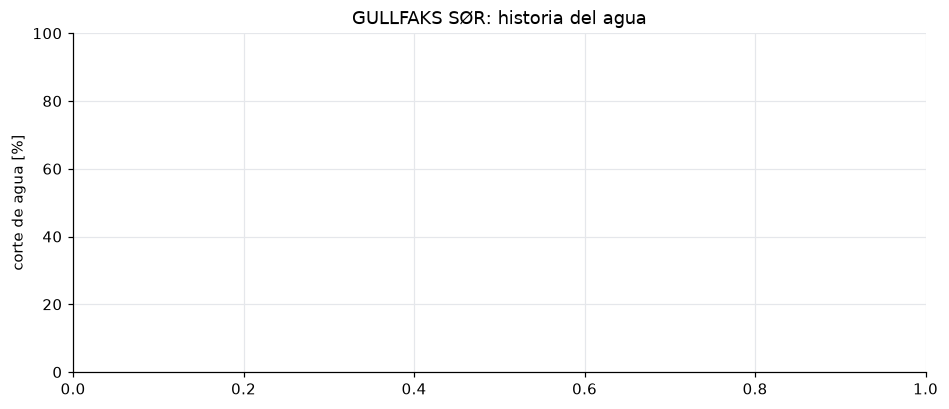

In [36]:
v = g[g.fecha >= TELON]

# TODO: grafiquen corte_movil(v) contra v.fecha
#       agreguen la linea del 50 % con ax.axhline(50, ...)
#       ¿la curva esta subiendo, plana, o bajando?

fig, ax = plt.subplots()
# ax.plot(...)
ax.set_ylim(0, 100)
ax.set_ylabel("corte de agua [%]")
ax.set_title(f"{MI_CAMPO}: historia del agua")
plt.show()

### Paso 3 · ¿A qué familia se parece?

Comparen la curva de su campo contra los tres centroides. Pista: si el campo
está en `curvas`, su asignación ya está calculada en `asignacion`.

In [37]:
# TODO: ¿esta MI_CAMPO en curvas? si si, ¿que familia le toco?
#       y si no esta, ¿por que? (revisen censurado(g))

if MI_CAMPO in asignacion:
    f = asignacion[MI_CAMPO]
    print(f"familia: {NOMBRES_FAM[f]}")
else:
    print(f"{MI_CAMPO} no tiene curva de familia.")
    print(f"¿censurado? {censurado(g)}")
    print("-> expliquen en una linea por que")

GULLFAKS SØR no tiene curva de familia.
¿censurado? True
-> expliquen en una linea por que


### Paso 4 · Los cuatro pronósticos y la banda

Calculen a mano lo que haría cada método. Ojo con el paso 4c: **hay que sacar
a Gullfaks Sør del grupo de análogos**, o se estaría comparando consigo mismo.

In [38]:
# 4a) el agua sigue igual
p_persistencia = wc_hoy

# 4b) su propia tendencia -- a 5 anios
p_tendencia = np.clip(wc_hoy + (wc_hoy - wc_ayer) * 5, 0, 0.99)

# 4c) TODO: analogos. Busquen en `s` los examenes de OTROS campos con
#     corte de hoy parecido (+-5 puntos) y tomen la mediana de wc_fut.
#     Calculen tambien los percentiles 10 y 90 -> la banda.
#
#     pista:  m = s[(np.abs(s.wc_hoy - wc_hoy) < 0.05) & (s.campo != MI_CAMPO)]
p_analogos = None
banda = (None, None)

# 4d) TODO: el bosque. Ya esta entrenado (rf_final). Necesitan armar la fila
#     de rasgos igual que en foto_de_hoy() -- o buscar el campo en `hoy`.
p_bosque = None

print(f"el agua sigue igual: {100*p_persistencia:.0f} %")
print(f"su propia tendencia: {100*p_tendencia:.0f} %")

el agua sigue igual: 34 %
su propia tendencia: 10 %


### Paso 5 · La pendiente negativa

Este campo **bajó** 5 puntos el último año. El método «su propia tendencia»
multiplica eso por cinco.

Miren el número que les dio `p_tendencia`. **¿Le creerían?** ¿Qué está
suponiendo ese método que un ingeniero sabe que no es cierto?

Escriban la respuesta acá abajo, en una o dos frases.

*(su respuesta:)*

### Paso 6 · La lista con presupuesto

De la tabla `lista` (la lista de vigilancia de hoy), tienen presupuesto para
vigilar **cinco** campos.

In [39]:
# TODO: elijan cinco. Prueben ordenar por criterios distintos:
#   - por corte esperado en 5 anios (columna 'bosque')
#   - por cuanto SUBE (bosque - wc_hoy)
#   - por barriles de agua en juego (bosque * oil_hoy)
# ¿dan la misma lista? ¿cual defenderian?

print(lista[["campo", "wc_hoy", "bosque", "oil_hoy"]].head(10).to_string(index=False))

         campo   wc_hoy   bosque       oil_hoy
JOHAN SVERDRUP 0.311363 0.593654 669608.891667
        GOLIAT 0.475787 0.554893  21825.266667
          FRAM 0.478311 0.481474  12551.141667
       VALHALL 0.385687 0.444329  27777.616667
  GULLFAKS SØR 0.341458 0.437595  20212.133333
           HOD 0.375097 0.423640   7235.666667
    KVITEBJØRN 0.383206 0.411719   5334.058333
       KRISTIN 0.238663 0.305510   6330.741667
      TYRIHANS 0.223635 0.304059   7806.725000
         SKARV 0.185897 0.237783  11148.541667


### Paso 7 · La pregunta de negocio

Escriban **dos frases** para el gerente de activos:

1. La primera dice **a qué campo le ampliarían la planta de agua y por qué**.
2. La segunda dice **qué dato les haría cambiar de opinión**.

La segunda frase es la que separa una recomendación de una corazonada. Un
gerente que escucha solo la primera no tiene cómo saber cuánta confianza
ponerle.

*(sus dos frases:)*

1.

2.

---

## Datos y referencias

- **Sokkeldirektoratet** (Norwegian Offshore Directorate) — *Production
  figures, monthly by field*. Datos abiertos, `factpages.sodir.no`. La misma
  fuente de la Clase 3, esta vez con las tres columnas.
- **Chan, K. S. (1995).** *Water Control Diagnostic Plots*. SPE 30775. El
  diagnóstico gráfico clásico del que salen conificación y canalización.
- El subconjunto se arma con `modulo5-clase4/preparar_datos.py`; las figuras
  del deck y **todas** sus cifras salen de `figuras.py`. Este cuaderno tiene
  que reproducirlas exactamente.

*Machine Learning for Petroleum Engineers Using Python* · SLB Ecuador / UDLA ·
2026